# ThermoProfiler Tutorial
*Predicting thermal rock properties (TC, SHC, TD) for sedimentary rocks from well logs*

This notebook demonstrates how to use **ThermoProfiler** to predict:
- Thermal Conductivity (**TC**)  
- Specific Heat Capacity (**SHC**)  
- Thermal Diffusivity (**TD**)  

The workflow is:
1. Load data into pandas dataframe 
2. Clean well log data.  
3. Choose a machine learning model (XGBoost, Random Forest, AdaBoost, or Linear).  
4. Run predictions using pre-trained models.  
5. Export results for further analysis or visualization.


### Install and Import

Make sure you have the correct versions of the required libraries installed:  

```bash
# MAKE TO USE CORRECT VERSIONS
pip install scikit-learn==1.2.1
pip install numpy==1.25.2
pip install pandas>=1.5.3
pip install joblib>=1.2.0
pip install lasio>=0.30.0


In [2]:
import pandas as pd
import numpy as np
from joblib import load
import sys
import os
sys.path.append(os.path.abspath("..")) 

sys.path.append(os.path.abspath("../thermoprofiler")) 

### Step 1 – Load Input Data

ThermoProfiler expects your well log data as a **tab-delimited TXT** or **CSV** file that can be read into a `pandas.DataFrame`.

Your file must contain the following well log columns (if available):
- `RHOB` → bulk density  
- `PHIN` → neutron porosity  
- `VSH` → shale volume (gamma-ray index)  
- `Vp` → compressional wave velocity  

In addition, you should provide:
- `Depth` → depth column (required)  
- Metadata such as `Stratigraphy`, `Rock_type`, `Lithology` (optional, but `Rock_type` is used for selecting the correct model)  

Missing logs are handled automatically → the tool will fall back to the best available log combination.

Example:
```python
import pandas as pd

# Load either a TXT (tab-delimited) or CSV file
df = pd.read_csv("input_logs.txt", sep="\t")   # for TXT
# df = pd.read_csv("input_logs.csv")           # for CSV

df.head()


In [10]:
df = pd.read_excel(
    r"C:\Users\dergun\Documents\thermoprofiler\Location_Meshalkin_etal._2020_Fig3_exp_TC.xlsx",
    #encoding="utf-16",   
    #sep="\t", 
    header=0
)
# Drop first row (often metadata) and reset index
df = df.drop(0).reset_index(drop=True)
df


,Depth,PHIN,Vp,RHOB,VSH,BTC_mov0.5m,Unnamed: 6,Rock_type
0,1251.98,14.6952,251.425,2.54708,0.440519,2.52007,clastic,3.0
1,1252.48,15.3618,255.986,2.58165,0.505155,2.51742,clastic,3.0
2,1252.98,15.2392,229.078,2.61216,0.422239,2.48577,clastic,3.0
3,1253.48,15.6066,240.25,2.58419,0.551276,3.22726,clastic,3.0
4,1253.98,15.0374,242.404,2.5573,0.692801,3.35067,clastic,3.0
...,...,...,...,...,...,...,...,...
612,1557.98,10.8283,225.978,2.42764,0.225917,2.65949,clastic,3.0
613,1558.48,10.8283,206.056,2.54488,0.232748,2.7435,clastic,3.0
614,1558.98,10.8283,210.798,2.54707,0.208299,2.6231,clastic,3.0
615,1559.48,10.8283,213.787,2.46022,0.175305,2.33949,clastic,3.0


### Step 2 – Preprocess and Clean Logs

ThermoProfiler provides a helper function to **clean and standardize your input DataFrame** before making predictions.  
This step ensures that:
- Column names are normalized (`RHOB`, `PHIN`, `VSH`, `VP`)  
- Missing or invalid values are handled (`-999` or blanks → converted to `NaN`)  
- Rock type IDs are formatted correctly (`1=Evaporites, 2=Carbonates, 3=Clastics`)  

```python
from thermoprofiler.preprocessing import clean_log_dataframe

df = clean_log_dataframe(df)



In [11]:
from thermoprofiler.preprocessing import clean_log_dataframe
df = clean_log_dataframe(df)
df


,Depth,PHIN,Vp,RHOB,VSH,BTC_mov0.5m,Unnamed: 6,Rock_type
0,1251.98,0.146952,251.425,2.54708,0.440519,2.52007,clastic,3.0
1,1252.48,0.153618,255.986,2.58165,0.505155,2.51742,clastic,3.0
2,1252.98,0.152392,229.078,2.61216,0.422239,2.48577,clastic,3.0
3,1253.48,0.156066,240.250,2.58419,0.551276,3.22726,clastic,3.0
4,1253.98,0.150374,242.404,2.55730,0.692801,3.35067,clastic,3.0
...,...,...,...,...,...,...,...,...
612,1557.98,0.108283,225.978,2.42764,0.225917,2.65949,clastic,3.0
613,1558.48,0.108283,206.056,2.54488,0.232748,2.7435,clastic,3.0
614,1558.98,0.108283,210.798,2.54707,0.208299,2.6231,clastic,3.0
615,1559.48,0.108283,213.787,2.46022,0.175305,2.33949,clastic,3.0


In [87]:
import sklearn, sys
print("RUNNING:", sys.executable, "sklearn:", sklearn.__version__)

RUNNING: c:\Users\dergun\miniforge3\envs\thermobase311\python.exe sklearn: 1.2.1


### Step 3 – Run Predictions

Now we can apply ThermoProfiler to compute thermal rock properties from the logs.  
The core function is:

```python
from thermoprofiler.prediction import predict_all_properties

results = predict_all_properties(df, model_type="XGBOOST")


In [ ]:

from thermoprofiler.prediction import predict_all_properties
from thermoprofiler.utils import to_multiindex_columns



RUNNING: c:\Users\dergun\miniforge3\envs\thermobase311\python.exe sklearn: 1.2.1



### Selection Modes

| Mode | Description | 
|------|-------------|
| `"ALL_LOGS"` | Uses all available logs in your dataframe (e.g. RHOB, PHIN, VSH, Vp → model 15) 
| `"MAPE"` | Selects the model with the lowest expected error for your rock type, using only the logs available 

### MultiIndex Output

`to_multiindex_columns()` reshapes the output into a two-level column structure:
```
prop        TC                          SHC                        TD
            prediction  Logs_used  ...  prediction  Logs_used  ...
```


In [13]:
df_mape_rf = predict_all_properties(df, model_type="RF", selection_mode="MAPE")
df_mape_rf = to_multiindex_columns(df_mape_rf)

df_all_xgboost = predict_all_properties(df, model_type="XGBOOST", selection_mode="ALL_LOGS")
df_all_xgb = to_multiindex_columns(df_all_xgboost)  

In [ ]:
df_mape_rf.head()
df_mape_rf.value_counts()
df_mape_rf.head(300)
#print(df_mape_rf["Logs_used"]) # MAPE


prop             TC               SHC            TD
0     RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
1     RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
2     RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
3     RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
4     RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
..              ...               ...           ...
612   RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
613   RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
614   RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
615   RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp
616   RHOB,PHIN,VSH  RHOB,PHIN,VSH,Vp  RHOB,PHIN,Vp

[617 rows x 3 columns]


In [9]:
df_all_xgb.head()
df_all_xgb.value_counts()
df_all_xgb.head(300)
#print(df_all_xgb["model_source"])  # ALL_LOGS
#print(df_all_xgb["model_path"])

metric    Depth      PHIN       Vp     RHOB       VSH BTC_mov0.5m Unnamed: 6  \
prop                                                                           
0       1251.98  0.146952  251.425  2.54708  0.440519     2.52007    clastic   
1       1252.48  0.153618  255.986  2.58165  0.505155     2.51742    clastic   
2       1252.98  0.152392  229.078  2.61216  0.422239     2.48577    clastic   
3       1253.48  0.156066  240.250  2.58419  0.551276     3.22726    clastic   
4       1253.98  0.150374  242.404  2.55730  0.692801     3.35067    clastic   
..          ...       ...      ...      ...       ...         ...        ...   
295     1399.48  0.045706  168.356  2.63120  0.029169     2.62112    clastic   
296     1399.98  0.045183  176.666  2.63478  0.019343     2.78039    clastic   
297     1400.48  0.045033  178.924  2.65484  0.046383       2.559    clastic   
298     1400.98  0.039211  172.875  2.64208  0.084978     2.43015    clastic   
299     1401.48  0.034819  168.953  2.64733  0.057336     2.82849    clastic   

metric Rock_type model_number expected_mape  ...         Logs_used  \
prop                       TC            TC  ...               SHC   
0              3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
1              3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
2              3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
3              3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
4              3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
..           ...          ...           ...  ...               ...   
295            3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
296            3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
297            3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
298            3           15           6.8  ...  RHOB,PHIN,VSH,Vp   
299            3           15           6.8  ...  RHOB,PHIN,VSH,Vp   

metric                                         model_path model_number  \
prop                                                  SHC           TD   
0       c:\Users\dergun\Documents\thermoprofiler\compi...           15   
1       c:\Users\dergun\Documents\thermoprofiler\compi...           15   
2       c:\Users\dergun\Documents\thermoprofiler\compi...           15   
3       c:\Users\dergun\Documents\thermoprofiler\compi...           15   
4       c:\Users\dergun\Documents\thermoprofiler\compi...           15   
..                                                    ...          ...   
295     c:\Users\dergun\Documents\thermoprofiler\compi...           15   
296     c:\Users\dergun\Documents\thermoprofiler\compi...           15   
297     c:\Users\dergun\Documents\thermoprofiler\compi...           15   
298     c:\Users\dergun\Documents\thermoprofiler\compi...           15   
299     c:\Users\dergun\Documents\thermoprofiler\compi...           15   

metric expected_mape model_source         Logs_used  \
prop              TD           TD                TD   
0                5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
1                5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
2                5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
3                5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
4                5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
..               ...          ...               ...   
295              5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
296              5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
297              5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
298              5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   
299              5.7     ALL_LOGS  RHOB,PHIN,VSH,Vp   

metric                                         model_path prediction  \
prop                                                   TD         TC   
0       c:\Users\dergun\Documents\thermoprofiler\compi...   2.814393   
1       c:\Users\dergun\Documents\thermoprofiler\compi...   2.807929   
2       c:\Users\dergun\Documents\thermoprofiler\compi...   3.169802   
3       c

### Step 4 – Export Results

After predictions are added to your DataFrame, you can export the results for further use.  
 

```python
from thermoprofiler.export import export_to_txt

# Save as tab-delimited TXT
export_to_txt(results, "predictions.txt")

# Save as CSV
results.to_csv("predictions.csv", index=False)



In [92]:
from thermoprofiler.export import export_to_txt, export_to_las
# export_to_txt(df, "predictions.txt")
df.to_csv("predictions.csv", index=False)

In [93]:
import matplotlib.pyplot as plt

def plot_tc_track_multiindex(
    df,
    curves,                 # list of (series, label) or list of (("metric","prop"), label)
    depth_key=("Depth", ""),# MultiIndex key for depth
    title="TC prediction"
):
    # --- depth series ---
    if isinstance(depth_key, tuple):
        depth = df[depth_key]
    else:
        depth = df[depth_key]

    # --- collect curve series ---
    series_list = []
    for spec, label in curves:
        if isinstance(spec, tuple):          # MultiIndex column key
            s = df[spec]
        else:                                
            s = spec
        series_list.append((s, label))

    # --- align, clean, sort by depth ---
    mask = depth.notna()
    for s, _ in series_list:
        mask &= s.notna()

    d = depth[mask].copy()
    order = d.argsort()
    d = d.iloc[order]

    series_list_sorted = [(s[mask].iloc[order], label) for s, label in series_list]

    # --- plot ---
    plt.figure(figsize=(4.2, 10.5)) 
    ax = plt.gca()

    for s, label in series_list_sorted:
        ax.plot(s.values, d.values, linewidth=1.2, label=label)

    ax.invert_yaxis()

    # x-axis on top (like a log track)
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", which="both", bottom=False, top=True, labelbottom=False, labeltop=True)

    ax.set_xlabel("TC")
    ax.set_ylabel("")  
    ax.set_title(title)

    # grid similar to screenshot
    ax.grid(True, which="major", axis="both", linewidth=0.8, alpha=0.4)

    # frame visible
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=1, frameon=False)

    plt.tight_layout()
    plt.show()



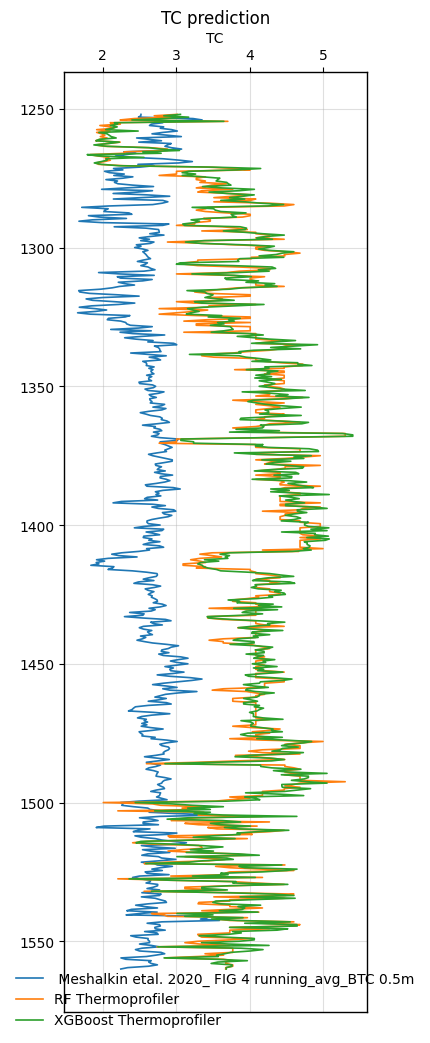

In [94]:
depth = df_all_xgb[("Depth","")]

plot_tc_track_multiindex(
    df_all_xgb,  
    curves=[
        (df_all_xgb[("BTC_mov0.5m")], " Meshalkin etal. 2020_ FIG 4 running_avg_BTC 0.5m"),
        (df_all_rf[("prediction","TC")], "RF Thermoprofiler"),
        (df_all_xgb[("prediction","TC")], "XGBoost Thermoprofiler"),
    ],
    depth_key=("Depth",""),
    title="TC prediction"
)


In [95]:
import numpy as np
import pandas as pd

def mape_rmspe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    ape = np.abs((y_true - y_pred) / y_true) * 100.0
    mape = ape.mean()

    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100.0
    return mape, rmspe, ape

depth = df_all_xgb[("Depth","")]

tc_ref = df_all_xgb[("BTC_mov0.5m","")]       
tc_pred_rf = df_all_rf[("prediction","TC")]   # RF-Run
tc_pred_xgb = df_all_xgb[("prediction","TC")] # XGB-Run


tmp = pd.DataFrame({
    "Depth": depth,
    "TC_ref": tc_ref,
    "TC_RF": tc_pred_rf,
    "TC_XGB": tc_pred_xgb
}).dropna()

mape_rf, rmspe_rf, ape_rf = mape_rmspe(tmp["TC_ref"], tmp["TC_RF"])
mape_xg, rmspe_xg, ape_xg = mape_rmspe(tmp["TC_ref"], tmp["TC_XGB"])

print(f"RF:    MAPE={mape_rf:.2f}%   RMSPE={rmspe_rf:.2f}%   N={len(tmp)}")
print(f"XGB:   MAPE={mape_xg:.2f}%   RMSPE={rmspe_xg:.2f}%   N={len(tmp)}")



RF:    MAPE=50.91%   RMSPE=55.45%   N=617
XGB:   MAPE=53.23%   RMSPE=57.39%   N=617


In [96]:
def flatten_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = [
            c[0] if c[1] == "" else f"{c[0]}_{c[1]}"
            for c in df.columns
        ]
    return df


In [97]:
import joblib
import pandas as pd

# Load model
model = joblib.load(r"C:\Users\dergun\Documents\thermoprofiler\compiled_models\Clastics\RF\TC\4.joblib")

# Check what features it was trained on
print(model.feature_names_in_)

# Select only the features the model expects, in the correct order
features = model.feature_names_in_
X = df[features]
X
# Predict
predictions = model.predict(X)

# Add predictions to your dataframe
df["TC_predicted"] = predictions
print(df[["Depth", "TC_predicted"]].head())
X

['Vp']
     Depth  TC_predicted
0  1251.98      4.566369
1  1252.48      4.566369
2  1252.98      4.566369
3  1253.48      4.566369
4  1253.98      4.566369


,Vp
0,251.425
1,255.986
2,229.078
3,240.25
4,242.404
...,...
612,225.978
613,206.056
614,210.798
615,213.787
